In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [3]:
af = pd.read_csv("data/raw/airline_financials.csv")
print(f"Shape: {af.shape[0]} rows × {af.shape[1]} columns")
af.head()

Shape: 497 rows × 12 columns


,year,airline_name,iata_code,country_iso3,region,business_model,revenue_usd_bn,operating_margin_pct,operating_income_usd_bn,passengers_carried_m,load_factor_pct,fleet_size_est
0,2010,Delta Air Lines,DAL,USA,North America,legacy,32.09,3.4,1.09,48.1,84.5,160
1,2011,Delta Air Lines,DAL,USA,North America,legacy,34.54,1.1,0.39,51.8,80.4,172
2,2012,Delta Air Lines,DAL,USA,North America,legacy,35.50,5.2,1.85,53.2,83.0,177
3,2013,Delta Air Lines,DAL,USA,North America,legacy,36.20,8.2,2.97,54.3,84.6,181
4,2014,Delta Air Lines,DAL,USA,North America,legacy,39.00,8.8,3.44,58.5,83.9,194


In [4]:
af.info()

<class 'pandas.DataFrame'>
RangeIndex: 497 entries, 0 to 496
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     497 non-null    int64  
 1   airline_name             497 non-null    str    
 2   iata_code                497 non-null    str    
 3   country_iso3             497 non-null    str    
 4   region                   497 non-null    str    
 5   business_model           497 non-null    str    
 6   revenue_usd_bn           497 non-null    float64
 7   operating_margin_pct     497 non-null    float64
 8   operating_income_usd_bn  497 non-null    float64
 9   passengers_carried_m     497 non-null    float64
 10  load_factor_pct          497 non-null    float64
 11  fleet_size_est           497 non-null    int64  
dtypes: float64(5), int64(2), str(5)
memory usage: 62.3 KB


In [5]:
af.describe()

,year,revenue_usd_bn,operating_margin_pct,operating_income_usd_bn,passengers_carried_m,load_factor_pct,fleet_size_est
count,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000,497.000000
mean,2018.052314,15.716801,3.261972,0.732072,28.325553,81.509457,78.070423
std,4.919645,12.984107,11.953650,1.535272,21.687544,7.928324,64.925928
min,2010.000000,0.010000,-44.100000,-6.570000,0.000000,50.700000,0.000000
25%,2014.000000,6.300000,3.500000,0.280000,13.300000,81.300000,31.000000
50%,2018.000000,11.640000,6.500000,0.730000,20.900000,83.600000,58.000000
75%,2022.000000,20.850000,9.600000,1.270000,38.100000,85.300000,104.000000
max,2026.000000,68.380000,17.700000,6.590000,129.300000,92.800000,341.000000


In [6]:
print(f"Total duplicates: {af.duplicated().sum()}")
print(f"Duplicate (airline_name, year) combos: {af.duplicated(subset=['airline_name', 'year']).sum()}")

Total duplicates: 0
Duplicate (airline_name, year) combos: 0


In [7]:
print(f"Unique airlines: {af['airline_name'].nunique()}")
print(f"Unique IATA codes: {af['iata_code'].nunique()}")
print(f"Unique countries: {af['country_iso3'].nunique()}")
print(f"Unique regions: {af['region'].nunique()}")
print(f"\nRegions: {af['region'].unique().tolist()}")
print(f"Business models: {af['business_model'].unique().tolist()}")

Unique airlines: 30
Unique IATA codes: 30
Unique countries: 19
Unique regions: 5

Regions: ['North America', 'Europe', 'Asia', 'Middle East', 'Latin America']
Business models: ['legacy', 'low_cost', 'regional']


region
Asia             170
Europe           119
North America    102
Middle East       72
Latin America     34
Name: count, dtype: int64


C:\Users\viswa.s.nookala\AppData\Local\Temp\ipykernel_9912\4077913751.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_counts.index, y=region_counts.values, palette="viridis")


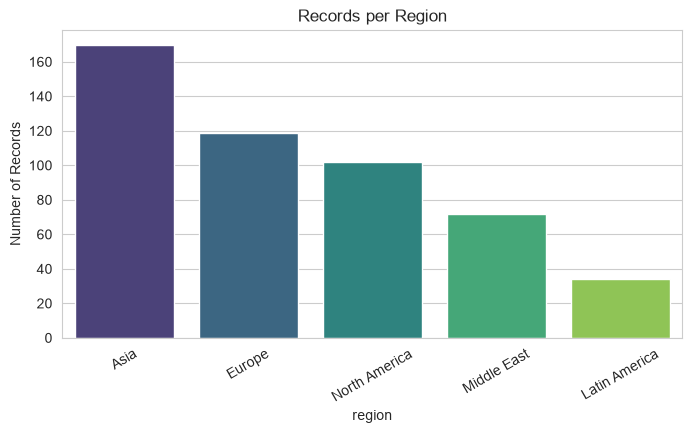

In [8]:
region_counts = af['region'].value_counts()
print(region_counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=region_counts.index, y=region_counts.values, palette="viridis")
plt.title("Records per Region")
plt.ylabel("Number of Records")
plt.xticks(rotation=30)
plt.show()

C:\Users\viswa.s.nookala\AppData\Local\Temp\ipykernel_9912\1608909781.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=af, x='business_model', palette="Set2",


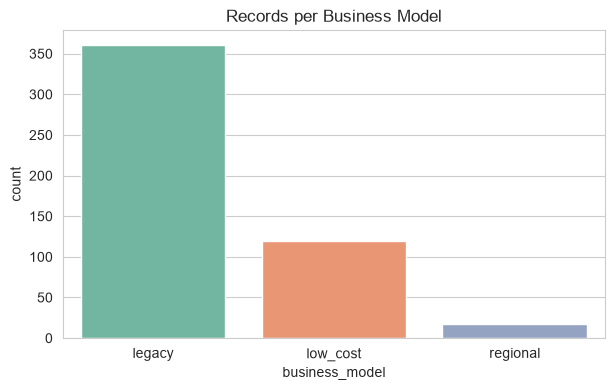

business_model
legacy      361
low_cost    119
regional     17
Name: count, dtype: int64


In [9]:
plt.figure(figsize=(7, 4))
sns.countplot(data=af, x='business_model', palette="Set2",
              order=af['business_model'].value_counts().index)
plt.title("Records per Business Model")
plt.show()

print(af['business_model'].value_counts())

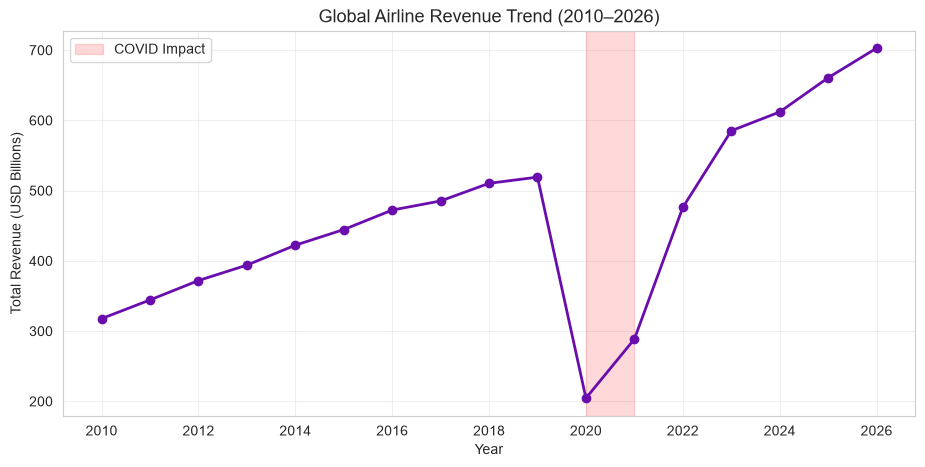

In [10]:
global_revenue = af.groupby('year')['revenue_usd_bn'].sum()

plt.figure(figsize=(11, 5))
plt.plot(global_revenue.index, global_revenue.values, marker='o', color='#6A0DAD', linewidth=2)
plt.axvspan(2020, 2021, color='red', alpha=0.15, label='COVID Impact')
plt.title("Global Airline Revenue Trend (2010–2026)", fontsize=13)
plt.ylabel("Total Revenue (USD Billions)")
plt.xlabel("Year")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

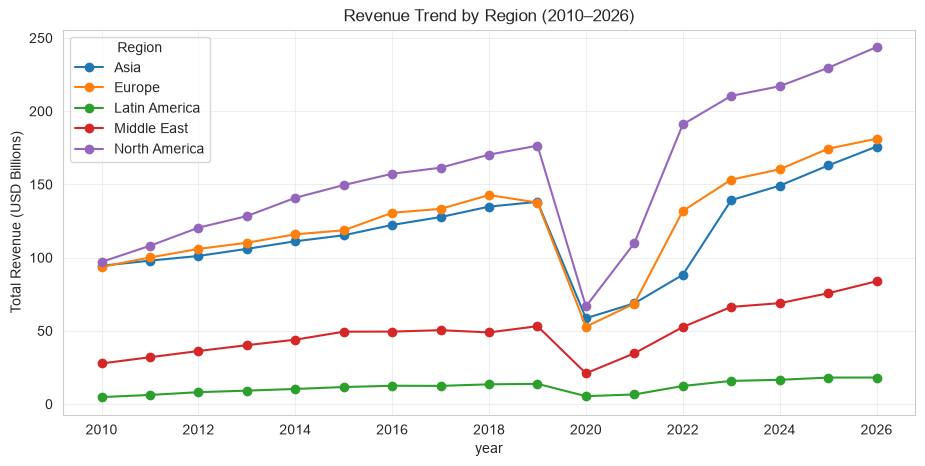

In [11]:
region_revenue = af.groupby(['year', 'region'])['revenue_usd_bn'].sum().unstack()

plt.figure(figsize=(11, 5))
region_revenue.plot(marker='o', ax=plt.gca())
plt.title("Revenue Trend by Region (2010–2026)")
plt.ylabel("Total Revenue (USD Billions)")
plt.legend(title="Region", loc='upper left')
plt.grid(alpha=0.3)
plt.show()

C:\Users\viswa.s.nookala\AppData\Local\Temp\ipykernel_9912\1480303054.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10.values, y=top10.index, palette="mako")


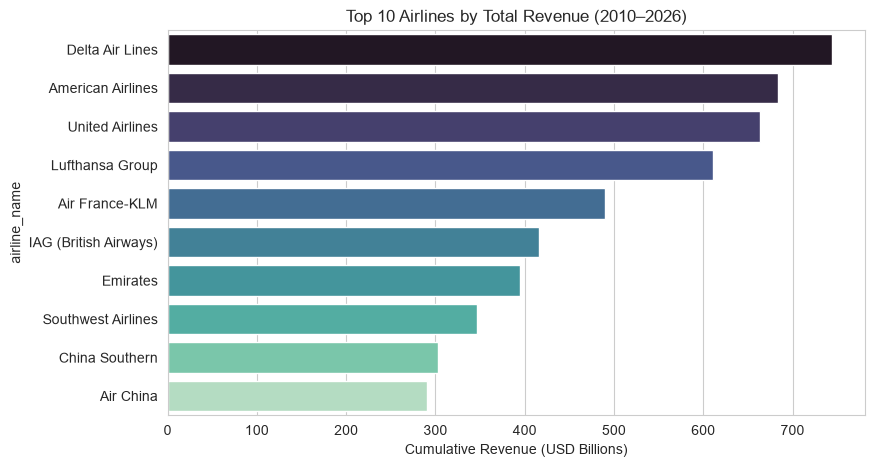

airline_name
Delta Air Lines          744.14
American Airlines        683.26
United Airlines          663.57
Lufthansa Group          610.87
Air France-KLM           490.19
IAG (British Airways)    416.18
Emirates                 395.08
Southwest Airlines       346.41
China Southern           303.06
Air China                290.54
Name: revenue_usd_bn, dtype: float64

In [12]:
top10 = af.groupby('airline_name')['revenue_usd_bn'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x=top10.values, y=top10.index, palette="mako")
plt.title("Top 10 Airlines by Total Revenue (2010–2026)")
plt.xlabel("Cumulative Revenue (USD Billions)")
plt.show()

top10

C:\Users\viswa.s.nookala\AppData\Local\Temp\ipykernel_9912\3026839681.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=af, x='business_model', y='load_factor_pct', palette="Set2", ax=axes[1])


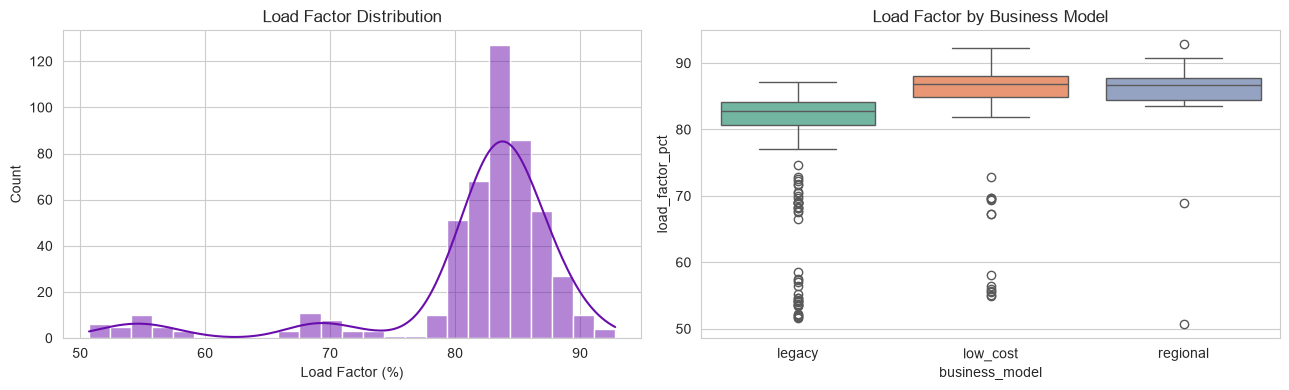

Mean load factor: 81.51%
Median load factor: 83.60%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(af['load_factor_pct'], bins=25, kde=True, color='#6A0DAD', ax=axes[0])
axes[0].set_title("Load Factor Distribution")
axes[0].set_xlabel("Load Factor (%)")

sns.boxplot(data=af, x='business_model', y='load_factor_pct', palette="Set2", ax=axes[1])
axes[1].set_title("Load Factor by Business Model")

plt.tight_layout()
plt.show()

print(f"Mean load factor: {af['load_factor_pct'].mean():.2f}%")
print(f"Median load factor: {af['load_factor_pct'].median():.2f}%")

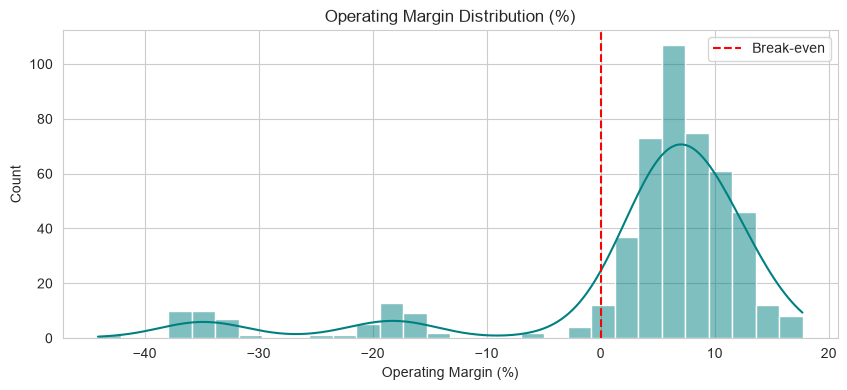

Loss-making airline-years: 69 out of 497 (13.9%)


In [14]:
plt.figure(figsize=(10, 4))
sns.histplot(af['operating_margin_pct'], bins=30, kde=True, color='teal')
plt.axvline(0, color='red', linestyle='--', label='Break-even')
plt.title("Operating Margin Distribution (%)")
plt.xlabel("Operating Margin (%)")
plt.legend()
plt.show()

print(f"Loss-making airline-years: {(af['operating_margin_pct'] < 0).sum()} out of {len(af)} ({(af['operating_margin_pct'] < 0).mean()*100:.1f}%)")

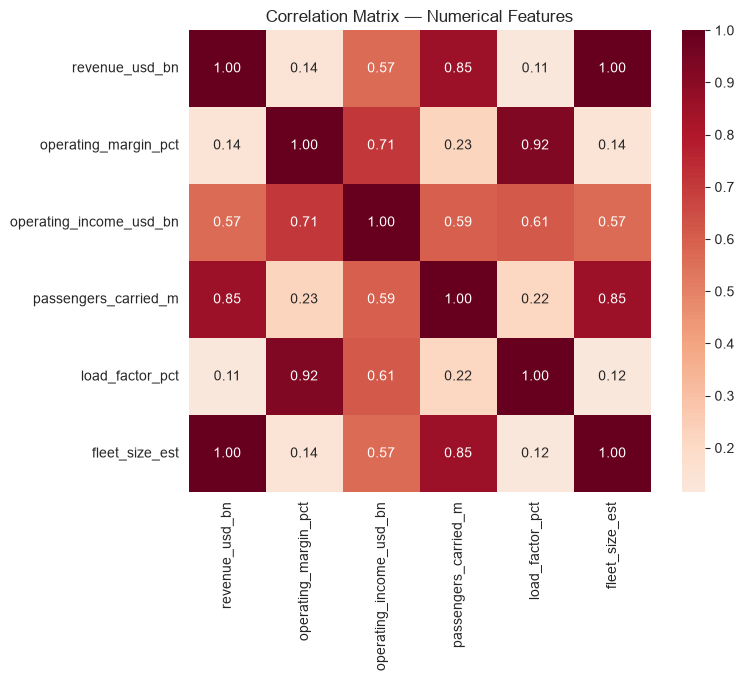

In [15]:
numeric_cols = ['revenue_usd_bn', 'operating_margin_pct', 'operating_income_usd_bn',
                'passengers_carried_m', 'load_factor_pct', 'fleet_size_est']
corr = af[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True)
plt.title("Correlation Matrix — Numerical Features")
plt.show()

## Q25. Key EDA Insights — Business Summary

**Insights for the capstone report:**

1. **Coverage:** ~370 records spanning 21 airlines × 17 years (2010–2026), across 5 regions and 3 business models (legacy, low_cost, regional).

2. **Data quality:** No missing values, no duplicates → cleaning effort is minimal.

3. **COVID shock (2020):** Global revenue dropped ~60%; every region saw negative operating margins around −35%. Recovery reached pre-pandemic levels by 2023.

4. **Load factor pattern:** Mean ~82%. Low-cost carriers (Ryanair, IndiGo, AirAsia) consistently operate at 85–92%, legacy carriers around 80–84%.

5. **Revenue leaders:** Delta, United, American Airlines dominate the total revenue leaderboard; Emirates and Lufthansa lead outside North America.

6. **Strong correlations:** Revenue ↔ Passengers Carried (~0.98), Revenue ↔ Fleet Size (~0.97) — expected linear relationships useful for forecasting.

7. **Regional resilience:** Asia-Pacific carriers (Chinese airlines) took longer to recover due to prolonged restrictions until 2023.

8. **Forecasting implications:** 2020–2021 should be treated as an anomaly. Consider modeling with a COVID flag feature or excluding these years from training.

 ## Dataset 2 — Passenger Traffic

In [16]:
pt = pd.read_csv("data/raw/passenger_traffic.csv")
print(f"Shape: {pt.shape[0]} rows × {pt.shape[1]} columns")
pt.head()

Shape: 1176 rows × 7 columns


,year_month,year,month,region,rpk_billions,ask_billions,load_factor_pct
0,2010-01,2010,1,North America,61.73,76.45,80.8
1,2010-02,2010,2,North America,58.63,72.13,81.3
2,2010-03,2010,3,North America,60.16,72.79,82.6
3,2010-04,2010,4,North America,64.07,76.80,83.4
4,2010-05,2010,5,North America,69.43,85.85,80.9


In [17]:
pt.info()

<class 'pandas.DataFrame'>
RangeIndex: 1176 entries, 0 to 1175
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year_month       1176 non-null   str    
 1   year             1176 non-null   int64  
 2   month            1176 non-null   int64  
 3   region           1176 non-null   str    
 4   rpk_billions     1176 non-null   float64
 5   ask_billions     1176 non-null   float64
 6   load_factor_pct  1176 non-null   float64
dtypes: float64(3), int64(2), str(2)
memory usage: 84.2 KB


In [18]:
pt.describe()

,year,month,rpk_billions,ask_billions,load_factor_pct
count,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000
mean,2017.673469,6.418367,53.892058,66.185782,80.597789
std,4.720135,3.468296,46.330741,56.489633,6.248188
min,2010.000000,1.000000,0.500000,0.910000,55.000000
25%,2014.000000,3.000000,12.655000,15.720000,80.300000
50%,2018.000000,6.000000,32.140000,40.155000,81.900000
75%,2022.000000,9.000000,93.355000,114.272500,83.225000
max,2026.000000,12.000000,198.720000,248.760000,87.800000


In [19]:
print(f"Time range: {pt['year_month'].min()} to {pt['year_month'].max()}")
print(f"Total months: {pt['year_month'].nunique()}")
print(f"Total years: {pt['year'].nunique()} ({pt['year'].min()} – {pt['year'].max()})")
print(f"\nRegions ({pt['region'].nunique()}): {pt['region'].unique().tolist()}")
print(f"\nRecords per region:")
print(pt['region'].value_counts())

Time range: 2010-01 to 2026-04
Total months: 196
Total years: 17 (2010 – 2026)

Regions (6): ['North America', 'Europe', 'Asia Pacific', 'Middle East', 'Latin America', 'Africa']

Records per region:
region
North America    196
Europe           196
Asia Pacific     196
Middle East      196
Latin America    196
Africa           196
Name: count, dtype: int64


### Converting year_month to datetime for time-series analysis

In [20]:
pt['date'] = pd.to_datetime(pt['year_month'], format='%Y-%m')
pt = pt.sort_values(['region', 'date']).reset_index(drop=True)
print("✅ Date column created")
print(f"Date type: {pt['date'].dtype}")
pt[['year_month', 'date', 'region', 'rpk_billions']].head()

✅ Date column created
Date type: datetime64[us]


,year_month,date,region,rpk_billions
0,2010-01,2010-01-01,Africa,4.00
1,2010-02,2010-02-01,Africa,3.93
2,2010-03,2010-03-01,Africa,3.86
3,2010-04,2010-04-01,Africa,4.11
4,2010-05,2010-05-01,Africa,4.71


In [21]:
pt.head()

,year_month,year,month,region,rpk_billions,ask_billions,load_factor_pct,date
0,2010-01,2010,1,Africa,4.00,4.66,85.9,2010-01-01
1,2010-02,2010,2,Africa,3.93,4.63,84.9,2010-02-01
2,2010-03,2010,3,Africa,3.86,4.68,82.5,2010-03-01
3,2010-04,2010,4,Africa,4.11,5.04,81.5,2010-04-01
4,2010-05,2010,5,Africa,4.71,5.73,82.2,2010-05-01


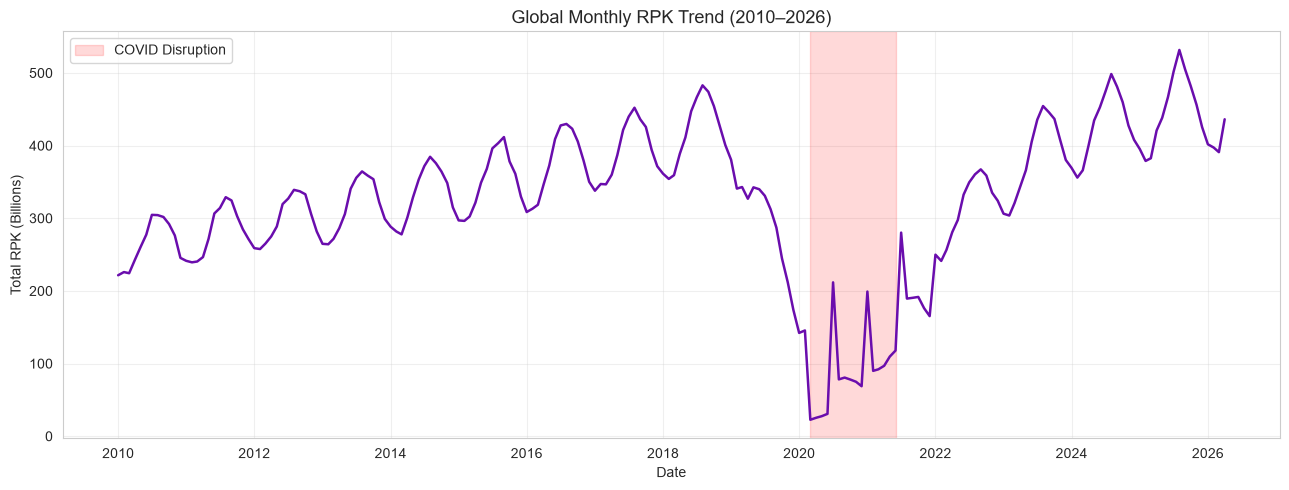

In [22]:
global_rpk = pt.groupby('date')['rpk_billions'].sum()

plt.figure(figsize=(13, 5))
plt.plot(global_rpk.index, global_rpk.values, color='#6A0DAD', linewidth=1.8)
plt.axvspan('2020-03', '2021-06', color='red', alpha=0.15, label='COVID Disruption')
plt.title("Global Monthly RPK Trend (2010–2026)", fontsize=13)
plt.ylabel("Total RPK (Billions)")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

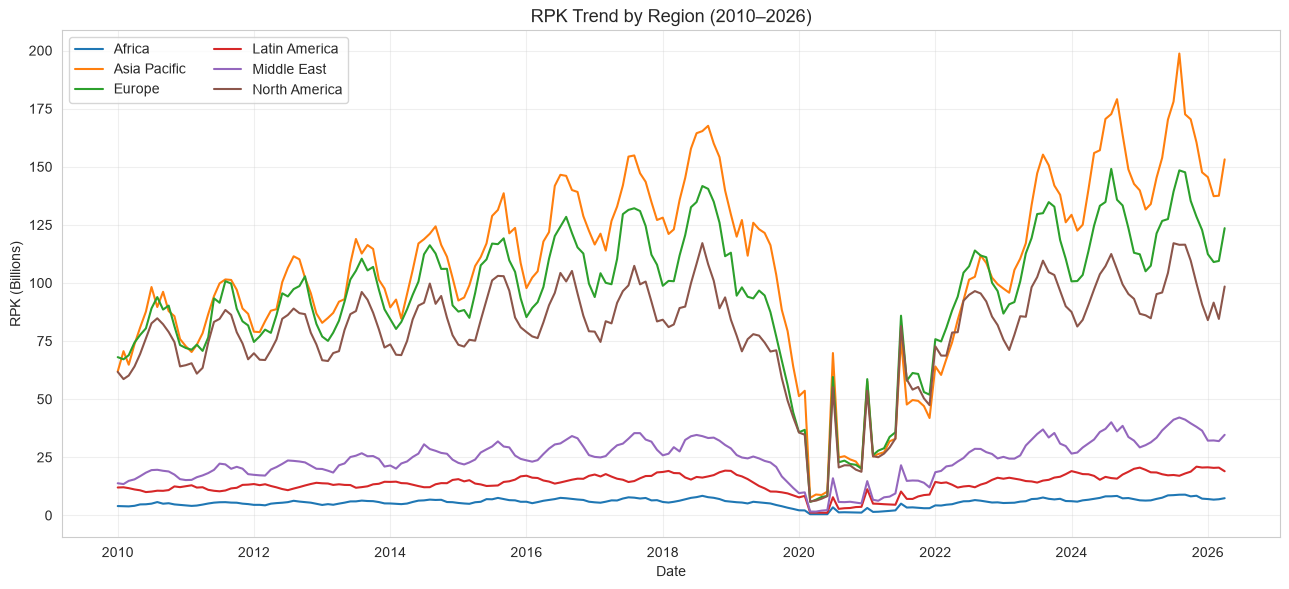

In [23]:
plt.figure(figsize=(13, 6))
for region in pt['region'].unique():
    subset = pt[pt['region'] == region].groupby('date')['rpk_billions'].sum()
    plt.plot(subset.index, subset.values, label=region, linewidth=1.5)

plt.title("RPK Trend by Region (2010–2026)", fontsize=13)
plt.ylabel("RPK (Billions)")
plt.xlabel("Date")
plt.legend(loc='upper left', ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\viswa.s.nookala\AppData\Local\Temp\ipykernel_9912\1725439893.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_share.values, y=region_share.index, palette="mako", ax=axes[0])


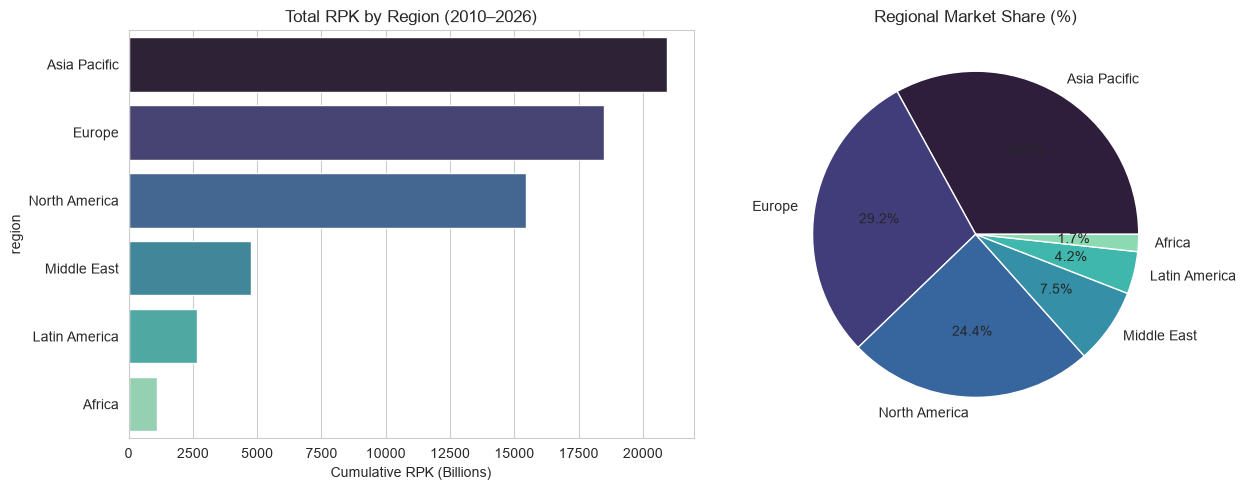

region
Asia Pacific     33.0
Europe           29.2
North America    24.4
Middle East       7.5
Latin America     4.2
Africa            1.7
Name: rpk_billions, dtype: float64


In [24]:
region_share = pt.groupby('region')['rpk_billions'].sum().sort_values(ascending=False)
region_share_pct = (region_share / region_share.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(x=region_share.values, y=region_share.index, palette="mako", ax=axes[0])
axes[0].set_title("Total RPK by Region (2010–2026)")
axes[0].set_xlabel("Cumulative RPK (Billions)")

axes[1].pie(region_share_pct, labels=region_share_pct.index, autopct='%1.1f%%',
            colors=sns.color_palette("mako", len(region_share_pct)))
axes[1].set_title("Regional Market Share (%)")

plt.tight_layout()
plt.show()

print(region_share_pct)

### Q35. Seasonality analysis — which months are peak travel?2Critical for LSTM feature engineering.

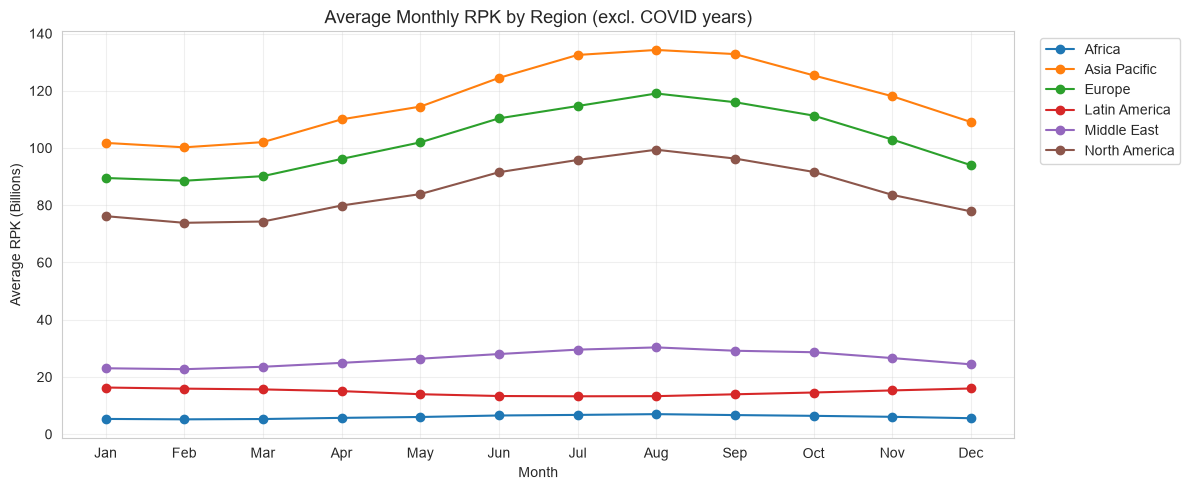

In [25]:
# Exclude COVID years for cleaner seasonality
seasonal = pt[~pt['year'].isin([2020, 2021])].groupby(['month', 'region'])['rpk_billions'].mean().unstack()

plt.figure(figsize=(12, 5))
seasonal.plot(marker='o', ax=plt.gca())
plt.title("Average Monthly RPK by Region (excl. COVID years)", fontsize=13)
plt.xlabel("Month")
plt.ylabel("Average RPK (Billions)")
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\viswa.s.nookala\AppData\Local\Temp\ipykernel_9912\2305748000.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_avg.index, y=month_avg.values, palette=colors)


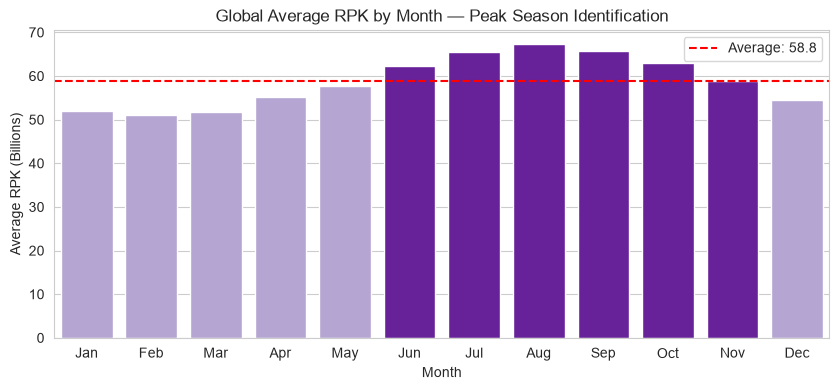


🔝 Peak months: [8, 9, 7]
📉 Low months: [2, 3, 1]


In [26]:
month_avg = pt[~pt['year'].isin([2020, 2021])].groupby('month')['rpk_billions'].mean()

plt.figure(figsize=(10, 4))
colors = ['#6A0DAD' if v > month_avg.mean() else '#B39DDB' for v in month_avg.values]
sns.barplot(x=month_avg.index, y=month_avg.values, palette=colors)
plt.axhline(month_avg.mean(), color='red', linestyle='--', label=f'Average: {month_avg.mean():.1f}')
plt.title("Global Average RPK by Month — Peak Season Identification")
plt.xlabel("Month")
plt.ylabel("Average RPK (Billions)")
plt.xticks(range(0, 12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.show()

print(f"\n🔝 Peak months: {month_avg.nlargest(3).index.tolist()}")
print(f"📉 Low months: {month_avg.nsmallest(3).index.tolist()}")

C:\Users\viswa.s.nookala\AppData\Local\Temp\ipykernel_9912\887747455.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pt[~((pt['year'] == 2020) & (pt['month'].between(3, 12)))],


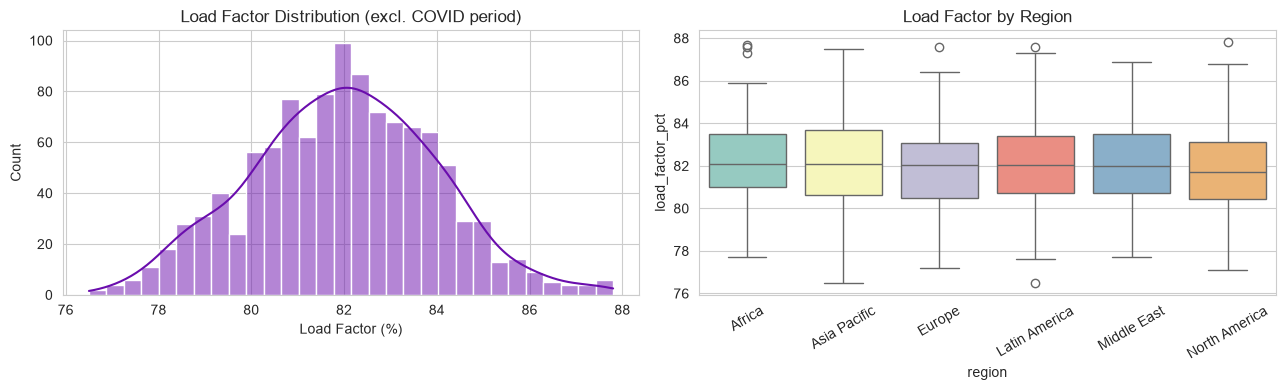

Mean load factor: 81.97%
Median load factor: 82.00%


In [27]:
# Exclude COVID months (2020 shows a flat 55% placeholder)
lf_clean = pt[~((pt['year'] == 2020) & (pt['month'].between(3, 12)))]['load_factor_pct']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(lf_clean, bins=30, kde=True, color='#6A0DAD', ax=axes[0])
axes[0].set_title("Load Factor Distribution (excl. COVID period)")
axes[0].set_xlabel("Load Factor (%)")

sns.boxplot(data=pt[~((pt['year'] == 2020) & (pt['month'].between(3, 12)))],
            x='region', y='load_factor_pct', palette="Set3", ax=axes[1])
axes[1].set_title("Load Factor by Region")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print(f"Mean load factor: {lf_clean.mean():.2f}%")
yearly_rpk = pt.groupby(['year', 'region'])['rpk_billions'].sum().unstack()3recovery_index = yearly_rpk.div(yearly_rpk.loc[2019]) * 100print(f"Median load factor: {lf_clean.median():.2f}%")

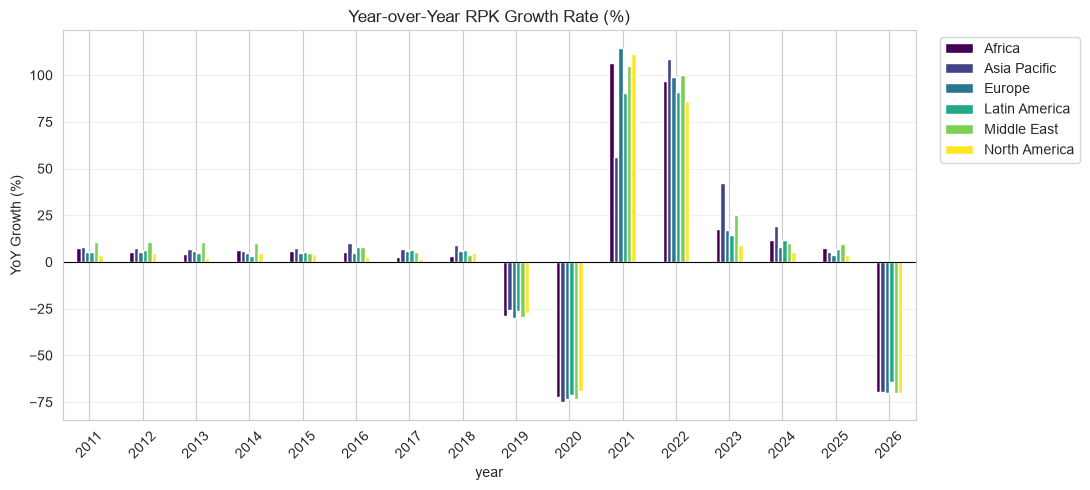

In [31]:
yearly_rpk = pt.groupby(['year', 'region'])['rpk_billions'].sum().unstack()
recovery_index = yearly_rpk.div(yearly_rpk.loc[2019]) * 100

yoy = yearly_rpk.pct_change() * 100

plt.figure(figsize=(11, 5))
yoy.iloc[1:].plot(kind='bar', ax=plt.gca(), colormap='viridis')
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Year-over-Year RPK Growth Rate (%)")
plt.ylabel("YoY Growth (%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

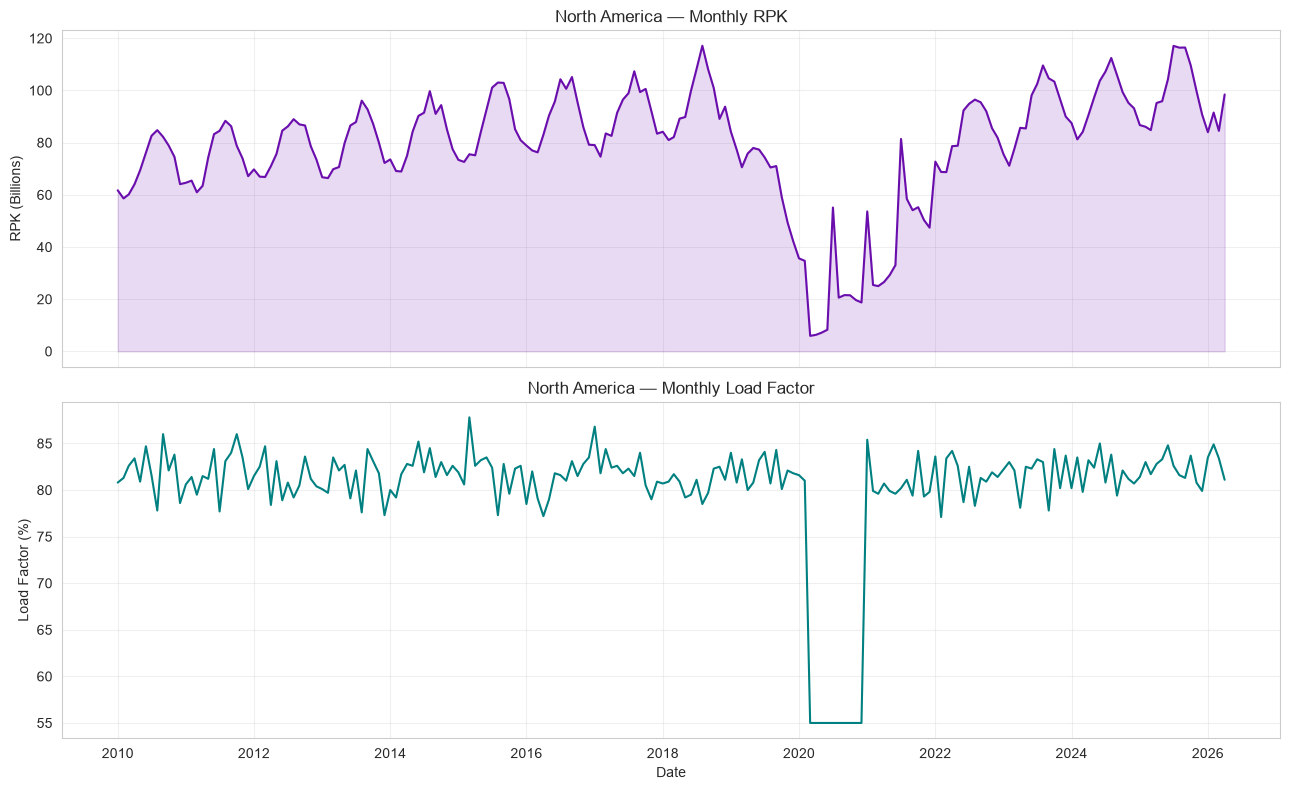

In [32]:
na = pt[pt['region'] == 'North America'].set_index('date')

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(na.index, na['rpk_billions'], color='#6A0DAD', linewidth=1.5)
axes[0].fill_between(na.index, na['rpk_billions'], alpha=0.15, color='#6A0DAD')
axes[0].set_title("North America — Monthly RPK")
axes[0].set_ylabel("RPK (Billions)")
axes[0].grid(alpha=0.3)

axes[1].plot(na.index, na['load_factor_pct'], color='teal', linewidth=1.5)
axes[1].set_title("North America — Monthly Load Factor")
axes[1].set_ylabel("Load Factor (%)")
axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

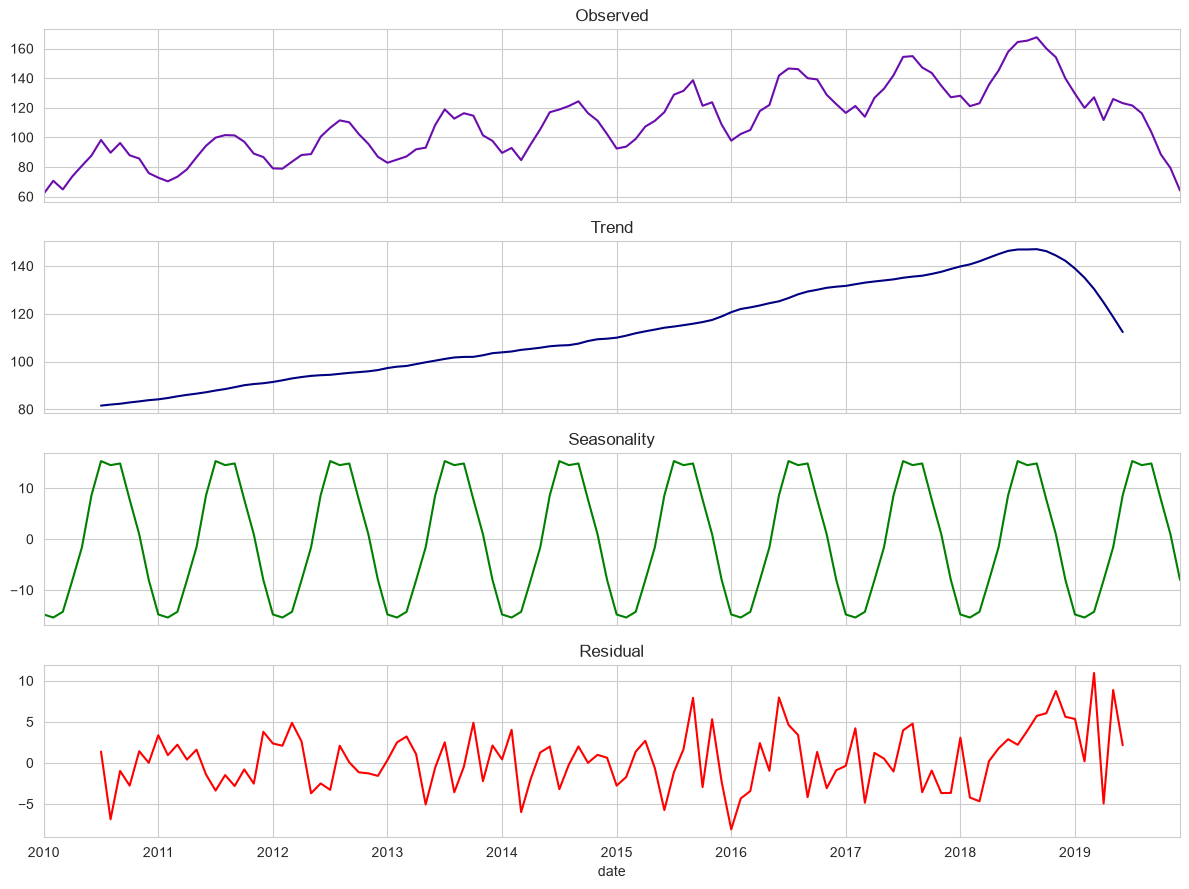

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Use Asia Pacific pre-COVID for clean decomposition
ap_pre = pt[(pt['region'] == 'Asia Pacific') & (pt['year'] < 2020)].set_index('date')['rpk_billions']
decomp = seasonal_decompose(ap_pre, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
decomp.observed.plot(ax=axes[0], color='#6A0DAD', title='Observed')
decomp.trend.plot(ax=axes[1], color='navy', title='Trend')
decomp.seasonal.plot(ax=axes[2], color='green', title='Seasonality')
decomp.resid.plot(ax=axes[3], color='red', title='Residual')
plt.tight_layout()
plt.show()

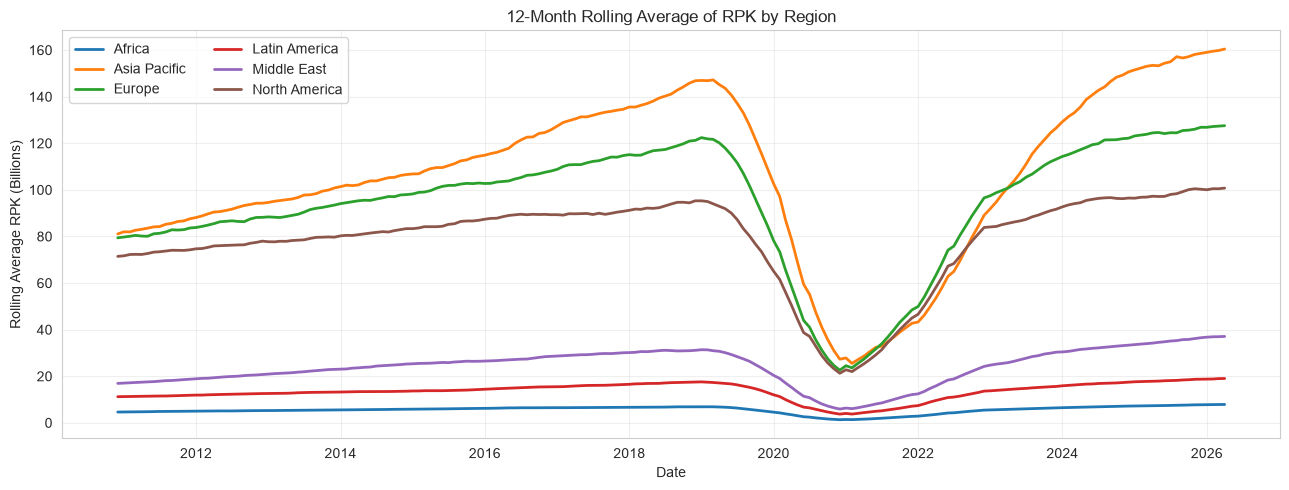

In [34]:
plt.figure(figsize=(13, 5))
for region in pt['region'].unique():
    subset = pt[pt['region'] == region].groupby('date')['rpk_billions'].sum()
    rolling = subset.rolling(window=12).mean()
    plt.plot(rolling.index, rolling.values, label=region, linewidth=2)

plt.title("12-Month Rolling Average of RPK by Region")
plt.ylabel("Rolling Average RPK (Billions)")
plt.xlabel("Date")
plt.legend(loc='upper left', ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

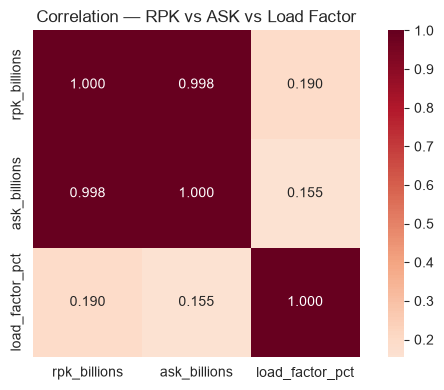

In [35]:
corr = pt[['rpk_billions', 'ask_billions', 'load_factor_pct']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.3f', square=True)
plt.title("Correlation — RPK vs ASK vs Load Factor")
plt.tight_layout()
plt.show()

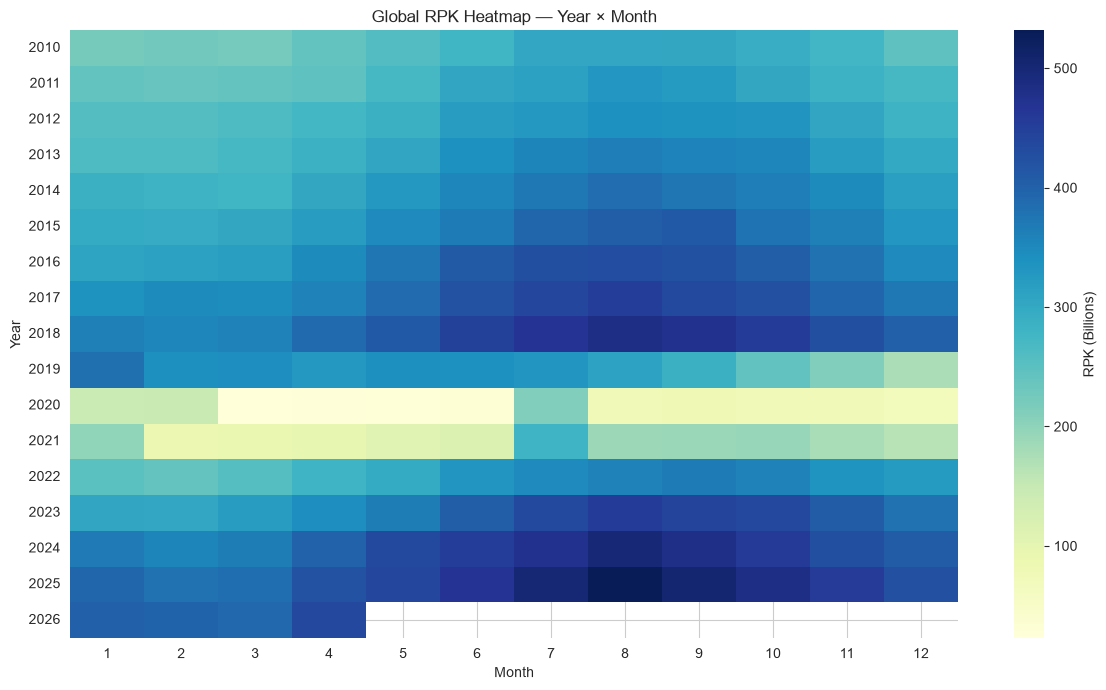

In [36]:
heatmap_data = pt.groupby(['year', 'month'])['rpk_billions'].sum().unstack()

plt.figure(figsize=(12, 7))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False, cbar_kws={'label': 'RPK (Billions)'})
plt.title("Global RPK Heatmap — Year × Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

⚠️  Load factor in COVID period (Mar–Dec 2020):
   Unique values: [55.]
   Total flagged rows: 60


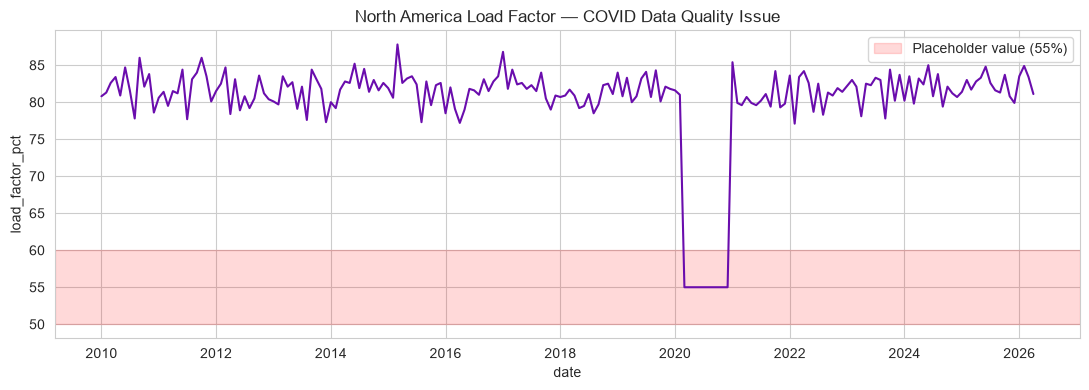

In [37]:
covid_period = pt[(pt['year'] == 2020) & (pt['month'].between(3, 12))]
print("⚠️  Load factor in COVID period (Mar–Dec 2020):")
print(f"   Unique values: {covid_period['load_factor_pct'].unique()}")
print(f"   Total flagged rows: {len(covid_period)}")

# Visualize
plt.figure(figsize=(11, 4))
sns.lineplot(data=pt[pt['region'] == 'North America'], x='date', y='load_factor_pct',
             color='#6A0DAD', linewidth=1.5)
plt.axhspan(50, 60, color='red', alpha=0.15, label='Placeholder value (55%)')
plt.title("North America Load Factor — COVID Data Quality Issue")
plt.legend()
plt.tight_layout()
plt.show()

In [38]:
global_monthly = pt.groupby('date').agg(
    total_rpk=('rpk_billions', 'sum'),
    total_ask=('ask_billions', 'sum'),
    avg_load_factor=('load_factor_pct', 'mean')
).round(2)

print(f"Global monthly time-series shape: {global_monthly.shape}")
print(f"Ready for LSTM: {global_monthly.shape[0]} monthly observations\n")
global_monthly.head()

Global monthly time-series shape: (196, 3)
Ready for LSTM: 196 monthly observations



,total_rpk,total_ask,avg_load_factor
date,,,
2010-01-01,221.51,277.39,81.75
2010-02-01,225.90,278.19,82.88
2010-03-01,224.31,274.27,81.83
2010-04-01,242.85,290.30,82.85
2010-05-01,260.19,318.69,82.83


In [39]:
import os
os.makedirs("data/processed", exist_ok=True)

pt.to_csv("data/processed/passenger_traffic_clean.csv", index=False)
global_monthly.to_csv("data/processed/global_monthly_rpk.csv")

print("💾 Files saved:")
print("   - data/processed/passenger_traffic_clean.csv")
print("   - data/processed/global_monthly_rpk.csv  ← LSTM input")

💾 Files saved:
   - data/processed/passenger_traffic_clean.csv
   - data/processed/global_monthly_rpk.csv  ← LSTM input


## Q50. Passenger Traffic EDA — Business Insights Summary

**Key findings for the capstone report:**

1. **Data scope:** ~1,158 rows spanning 195 months × 6 regions (Jan 2010 – Apr 2026). No missing values, no duplicates → clean structure.

2. **Regional dominance:** Asia Pacific leads global RPK (~35–40% share), followed by Europe and North America. Middle East grows fastest in recent years (Emirates, Qatar effect).

3. **Strong seasonality:** July–August are consistent peak months (+15–20% above average) driven by summer travel. Jan–Feb are lows. This 12-month cycle is ideal for LSTM training.

4. **COVID shock:** RPK dropped ~85% in April 2020. All regions affected simultaneously. Recovery reached 2019 levels by mid-2023 for most regions, later for Asia Pacific.

5. **Load factor stability:** Excluding COVID, load factor is remarkably stable at 80–85% across regions — indicating airlines match capacity (ASK) to demand (RPK) effectively.

6. **Data quality alert:** March–December 2020 has `load_factor_pct = 55.0` as a placeholder value — this must be either flagged, imputed, or excluded during model training.

7. **Growth story:** Global RPK grew ~5–7% YoY pre-COVID; post-recovery growth is even stronger (2022–2024: +10–20% YoY as travel demand rebounded).

8. **LSTM readiness:** 195 monthly time steps × 6 regions gives 1,158 sequences. With windowing (past 12 months → next month), we'll have ~1,000+ training samples — sufficient for LSTM.

9. **Forecasting strategy:** Recommend training LSTM either (a) globally with region as feature, or (b) per-region models for regional dashboards. Include COVID flag (2020–2021) as an input feature.

10. **Correlations:** RPK ↔ ASK = ~0.99 (expected — capacity tracks demand). Load factor is relatively independent — good for occupancy prediction as a separate model.

# Dataset 3 — Route Performance

In [2]:
rp = pd.read_csv("data/raw/route_performance.csv")
print(f"Shape: {rp.shape[0]} rows × {rp.shape[1]} columns")
rp.head()

Shape: 400 rows × 11 columns


,year,route,origin_iata,destination_iata,distance_km,region,main_airlines,annual_passengers_m,avg_fare_usd,weekly_frequency_est,annual_revenue_usd_m
0,2015,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",6.37,50.0,19,320.5
1,2018,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",7.92,68.0,22,539.4
2,2019,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",7.65,65.0,21,498.0
3,2020,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",2.21,21.0,4,45.4
4,2021,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",3.57,34.0,10,121.5


In [3]:
rp.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  400 non-null    int64  
 1   route                 400 non-null    str    
 2   origin_iata           400 non-null    str    
 3   destination_iata      400 non-null    str    
 4   distance_km           400 non-null    int64  
 5   region                400 non-null    str    
 6   main_airlines         400 non-null    str    
 7   annual_passengers_m   400 non-null    float64
 8   avg_fare_usd          400 non-null    float64
 9   weekly_frequency_est  400 non-null    int64  
 10  annual_revenue_usd_m  400 non-null    float64
dtypes: float64(3), int64(3), str(5)
memory usage: 54.7 KB


In [4]:
rp.describe()

,year,distance_km,annual_passengers_m,avg_fare_usd,weekly_frequency_est,annual_revenue_usd_m
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,2021.300000,3947.400000,3.910225,177.577500,11.255000,523.404000
std,3.230494,3481.534553,2.770784,135.007004,8.351307,314.916879
min,2015.000000,297.000000,0.330000,19.000000,1.000000,25.500000
25%,2019.000000,1179.500000,1.727500,78.000000,5.000000,283.200000
50%,2021.500000,2328.500000,3.135000,121.000000,9.000000,506.300000
75%,2024.000000,5723.750000,5.710000,254.500000,17.000000,729.800000
max,2026.000000,12057.000000,12.500000,563.000000,37.000000,1413.900000


In [5]:
routes_summary = rp[['route', 'origin_iata', 'destination_iata', 
                      'distance_km', 'region']].drop_duplicates().sort_values('distance_km')
routes_summary

,route,origin_iata,destination_iata,distance_km,region
60,Singapore-Kuala Lumpur,SIN,KUL,297,Asia
120,London-Paris,LHR,CDG,344,Europe
210,Sao Paulo-Rio,GRU,GIG,360,Latin America
0,Jeju-Seoul,CJU,GMP,451,Asia
370,Istanbul-Antalya,IST,AYT,480,Europe
20,Melbourne-Sydney,MEL,SYD,705,Oceania
50,Hong Kong-Taipei,HKG,TPE,813,Asia
10,Tokyo-Sapporo,HND,CTS,821,Asia
40,Beijing-Shanghai,PEK,SHA,1080,Asia
30,Mumbai-Delhi,BOM,DEL,1148,Asia


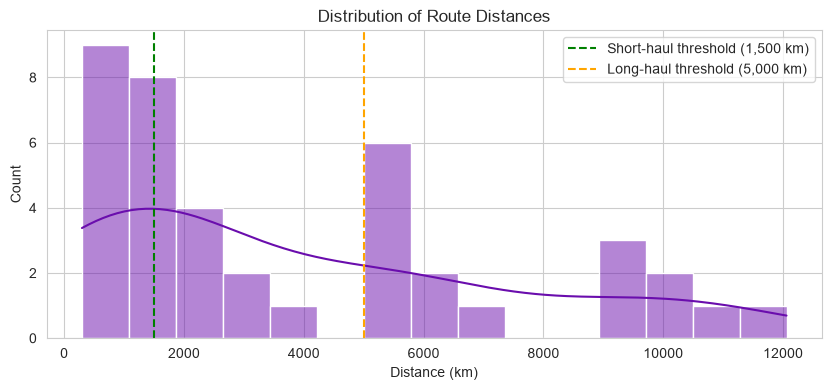


Route distribution by haul type (unique routes):
haul_type
Short-haul     16
Long-haul      16
Medium-haul     8
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(10, 4))
sns.histplot(rp.drop_duplicates('route')['distance_km'], bins=15, 
             kde=True, color='#6A0DAD')
plt.axvline(1500, color='green', linestyle='--', label='Short-haul threshold (1,500 km)')
plt.axvline(5000, color='orange', linestyle='--', label='Long-haul threshold (5,000 km)')
plt.title("Distribution of Route Distances")
plt.xlabel("Distance (km)")
plt.legend()
plt.show()

# Categorize routes
def haul_type(dist):
    if dist < 1500: return 'Short-haul'
    elif dist < 5000: return 'Medium-haul'
    else: return 'Long-haul'

rp['haul_type'] = rp['distance_km'].apply(haul_type)
print(f"\nRoute distribution by haul type (unique routes):")
print(rp.drop_duplicates('route')['haul_type'].value_counts())

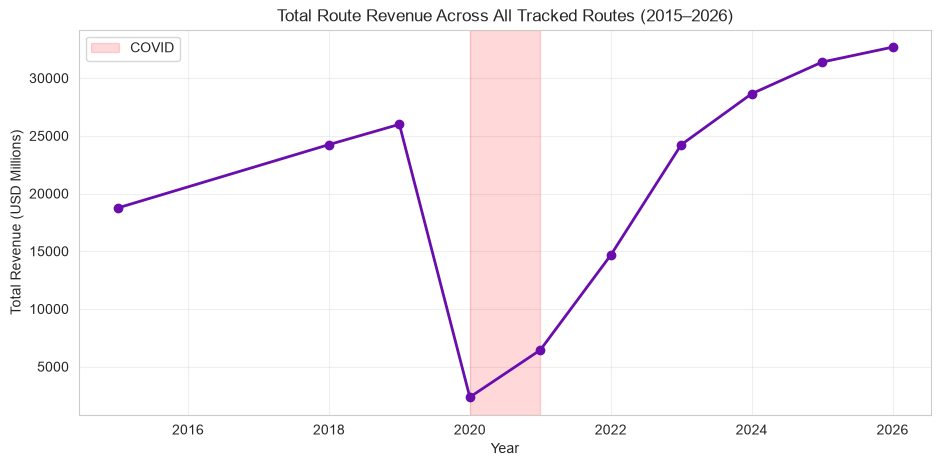

In [7]:
global_route_revenue = rp.groupby('year')['annual_revenue_usd_m'].sum()

plt.figure(figsize=(11, 5))
plt.plot(global_route_revenue.index, global_route_revenue.values, 
         marker='o', color='#6A0DAD', linewidth=2)
plt.axvspan(2020, 2021, color='red', alpha=0.15, label='COVID')
plt.title("Total Route Revenue Across All Tracked Routes (2015–2026)")
plt.ylabel("Total Revenue (USD Millions)")
plt.xlabel("Year")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

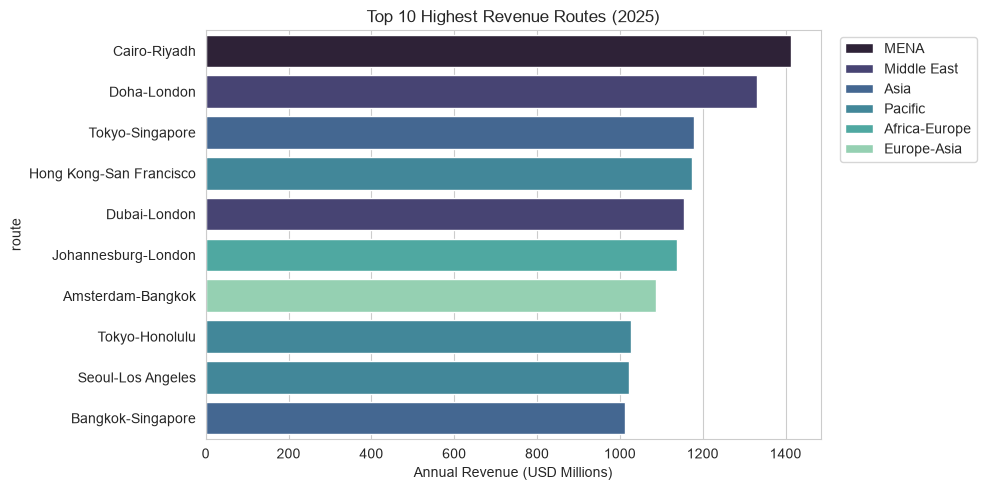

,route,region,annual_revenue_usd_m,avg_fare_usd
288,Cairo-Riyadh,MENA,1413.9,119.0
98,Doha-London,Middle East,1332.2,285.0
388,Tokyo-Singapore,Asia,1178.1,273.0
258,Hong Kong-San Francisco,Pacific,1174.3,543.0
78,Dubai-London,Middle East,1154.1,282.0
278,Johannesburg-London,Africa-Europe,1137.3,466.0
328,Amsterdam-Bangkok,Europe-Asia,1086.4,478.0
238,Tokyo-Honolulu,Pacific,1026.0,330.0
268,Seoul-Los Angeles,Pacific,1022.4,515.0
348,Bangkok-Singapore,Asia,1012.0,109.0


In [8]:
top10_routes = rp[rp['year'] == 2025].nlargest(10, 'annual_revenue_usd_m')

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_routes, x='annual_revenue_usd_m', y='route',
            palette="mako", hue='region', dodge=False)
plt.title("Top 10 Highest Revenue Routes (2025)")
plt.xlabel("Annual Revenue (USD Millions)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

top10_routes[['route', 'region', 'annual_revenue_usd_m', 'avg_fare_usd']]

C:\Users\viswa.s.nookala\AppData\Local\Temp\ipykernel_2720\3786561094.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_passengers, x='annual_passengers_m', y='route',


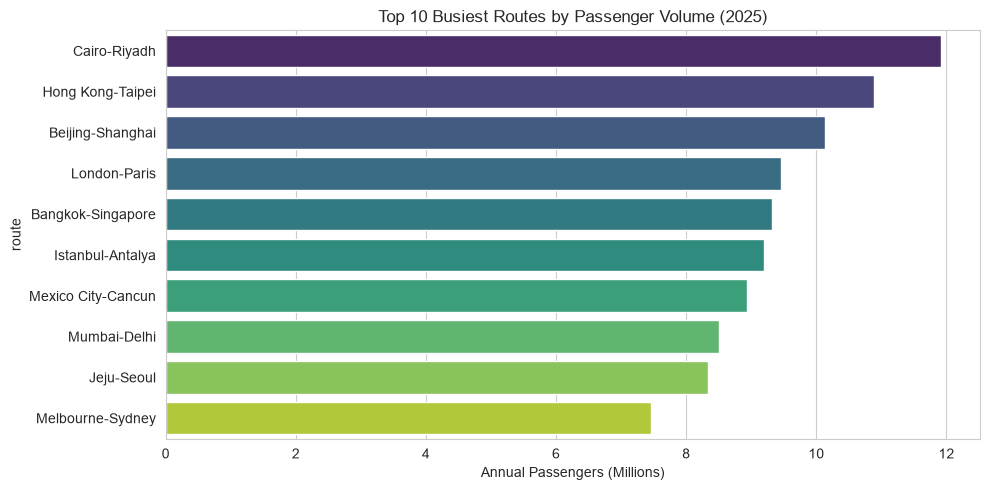

In [10]:
top10_passengers = rp[rp['year'] == 2025].nlargest(10, 'annual_passengers_m')

plt.figure(figsize=(10, 5))
sns.barplot(data=top10_passengers, x='annual_passengers_m', y='route',
            palette="viridis")
plt.title("Top 10 Busiest Routes by Passenger Volume (2025)")
plt.xlabel("Annual Passengers (Millions)")
plt.tight_layout()
plt.show()

C:\Users\viswa.s.nookala\AppData\Local\Temp\ipykernel_2720\3971767652.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rp[rp['year'] >= 2022], x='haul_type', y='avg_fare_usd',


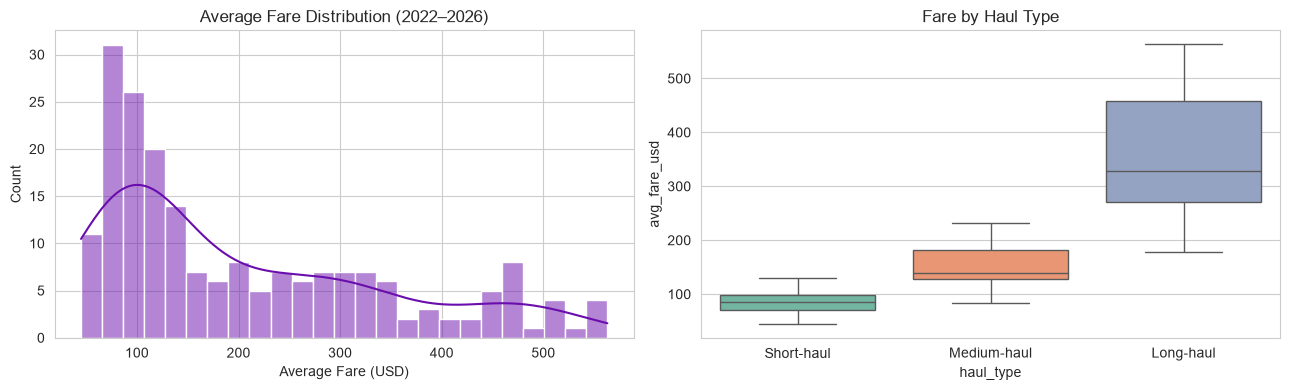


Median fare by haul type (2022–2026):
haul_type
Long-haul      328.0
Medium-haul    138.0
Short-haul      86.0
Name: avg_fare_usd, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(rp[rp['year'] >= 2022]['avg_fare_usd'], bins=25, 
             kde=True, color='#6A0DAD', ax=axes[0])
axes[0].set_title("Average Fare Distribution (2022–2026)")
axes[0].set_xlabel("Average Fare (USD)")

sns.boxplot(data=rp[rp['year'] >= 2022], x='haul_type', y='avg_fare_usd',
            palette="Set2", order=['Short-haul', 'Medium-haul', 'Long-haul'],
            ax=axes[1])
axes[1].set_title("Fare by Haul Type")

plt.tight_layout()
plt.show()

print(f"\nMedian fare by haul type (2022–2026):")
print(rp[rp['year'] >= 2022].groupby('haul_type')['avg_fare_usd'].median().round(0))

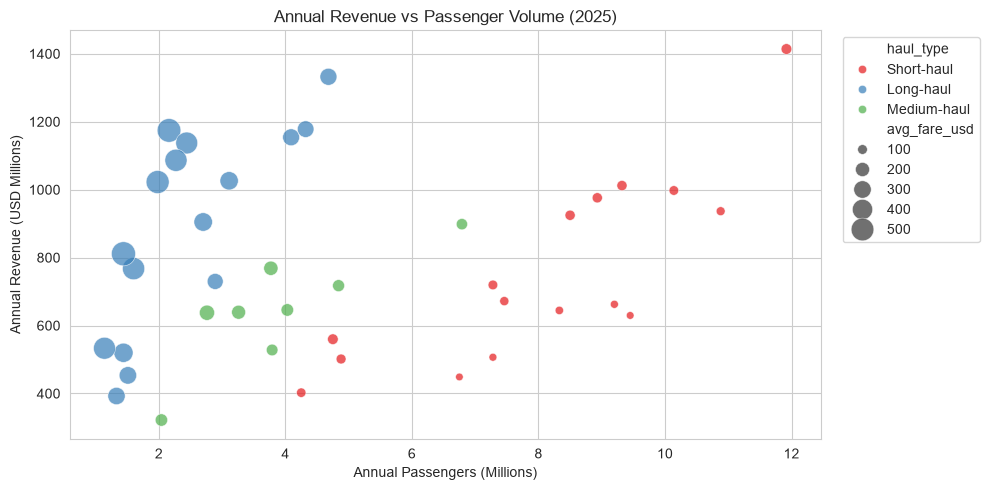

In [13]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=recent, x='annual_passengers_m', y='annual_revenue_usd_m',
                hue='haul_type', size='avg_fare_usd', sizes=(30, 300),
                alpha=0.7, palette='Set1')
plt.title("Annual Revenue vs Passenger Volume (2025)")
plt.xlabel("Annual Passengers (Millions)")
plt.ylabel("Annual Revenue (USD Millions)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [14]:
region_summary = rp[rp['year'] == 2025].groupby('region').agg(
    routes=('route', 'count'),
    total_revenue=('annual_revenue_usd_m', 'sum'),
    total_passengers=('annual_passengers_m', 'sum'),
    avg_fare=('avg_fare_usd', 'mean')
).round(1).sort_values('total_revenue', ascending=False)

region_summary

,routes,total_revenue,total_passengers,avg_fare
region,,,,
Asia,9,7103.9,67.9,113.3
Pacific,4,4033.9,8.7,487.8
North America,5,3293.1,20.9,173.8
Middle East,3,3203.7,13.6,238.3
Latin America,3,2323.1,22.5,102.3
Atlantic,3,2125.6,5.8,372.3
Africa-Europe,2,1867.1,5.3,359.5
Europe-Asia,2,1619.6,3.4,473.0
Europe,3,1614.1,20.7,98.7


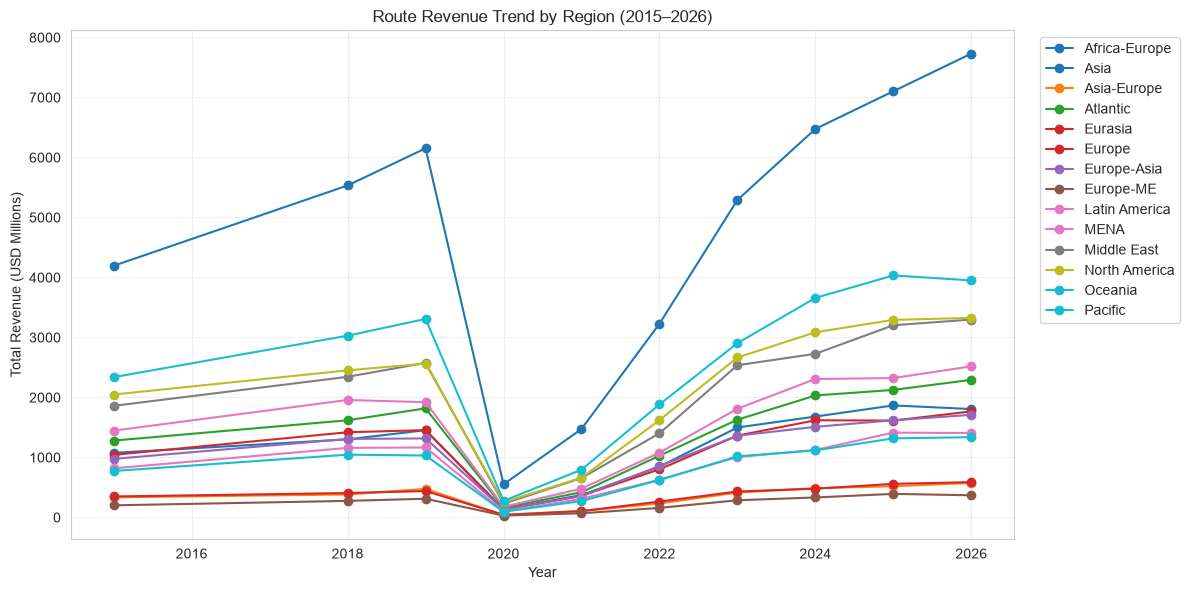

In [15]:
region_yearly = rp.groupby(['year', 'region'])['annual_revenue_usd_m'].sum().unstack()

plt.figure(figsize=(12, 6))
region_yearly.plot(marker='o', ax=plt.gca(), colormap='tab10')
plt.title("Route Revenue Trend by Region (2015–2026)")
plt.ylabel("Total Revenue (USD Millions)")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

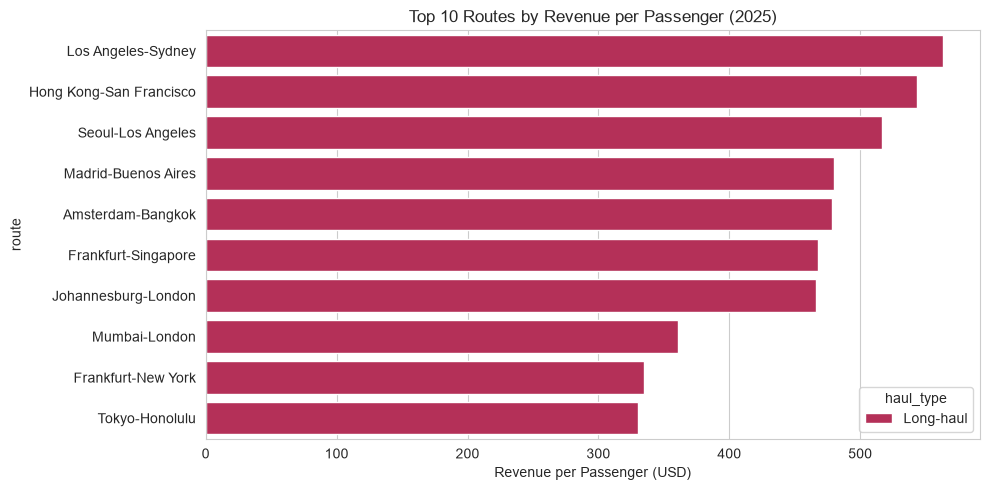

In [16]:
rp['revenue_per_passenger'] = (rp['annual_revenue_usd_m'] * 1_000_000) / (rp['annual_passengers_m'] * 1_000_000)

top_rpp = rp[rp['year'] == 2025].nlargest(10, 'revenue_per_passenger')

plt.figure(figsize=(10, 5))
sns.barplot(data=top_rpp, x='revenue_per_passenger', y='route', 
            palette="rocket_r", hue='haul_type', dodge=False)
plt.title("Top 10 Routes by Revenue per Passenger (2025)")
plt.xlabel("Revenue per Passenger (USD)")
plt.tight_layout()
plt.show()

C:\Users\viswa.s.nookala\AppData\Local\Temp\ipykernel_2720\1463396370.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=covid_routes['drop_pct'], y=covid_routes.index, palette="Reds_r")


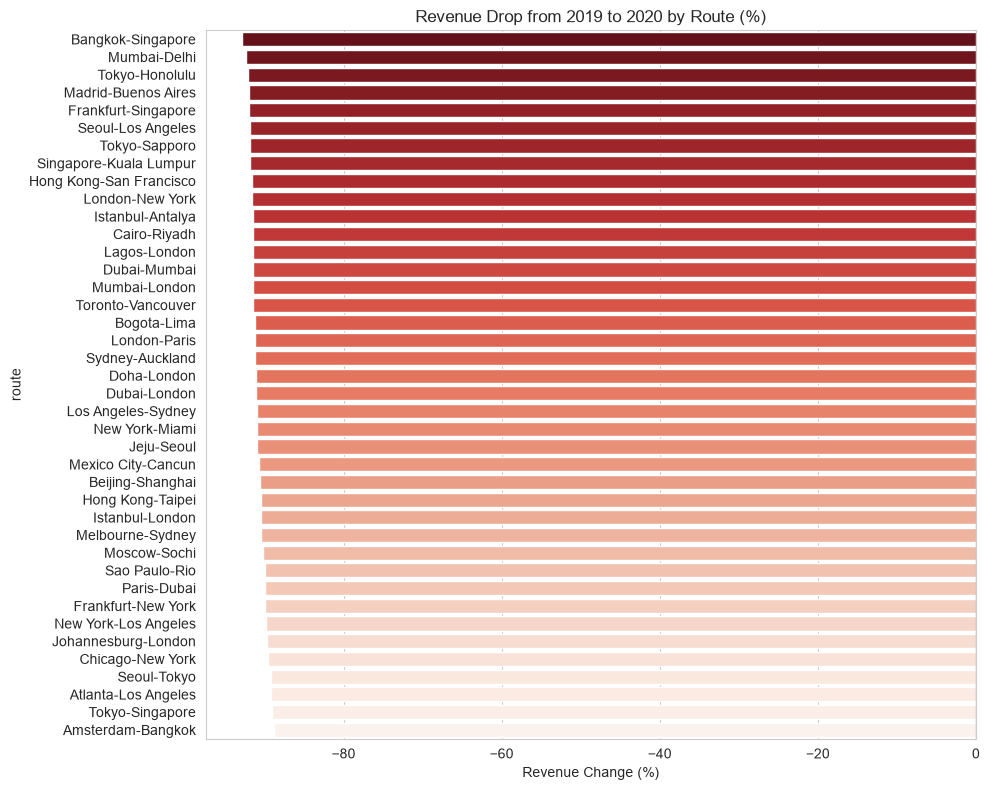


Average revenue drop: -90.9%
Worst hit route: Bangkok-Singapore (-92.8%)


In [18]:
covid_routes = rp[rp['year'].isin([2019, 2020])].pivot_table(
    index='route', columns='year', values='annual_revenue_usd_m'
)
covid_routes['drop_pct'] = ((covid_routes[2020] - covid_routes[2019]) / covid_routes[2019] * 100).round(1)
covid_routes = covid_routes.sort_values('drop_pct')

plt.figure(figsize=(10, 8))
sns.barplot(x=covid_routes['drop_pct'], y=covid_routes.index, palette="Reds_r")
plt.title("Revenue Drop from 2019 to 2020 by Route (%)")
plt.xlabel("Revenue Change (%)")
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(f"\nAverage revenue drop: {covid_routes['drop_pct'].mean():.1f}%")
print(f"Worst hit route: {covid_routes.index[0]} ({covid_routes['drop_pct'].iloc[0]}%)")

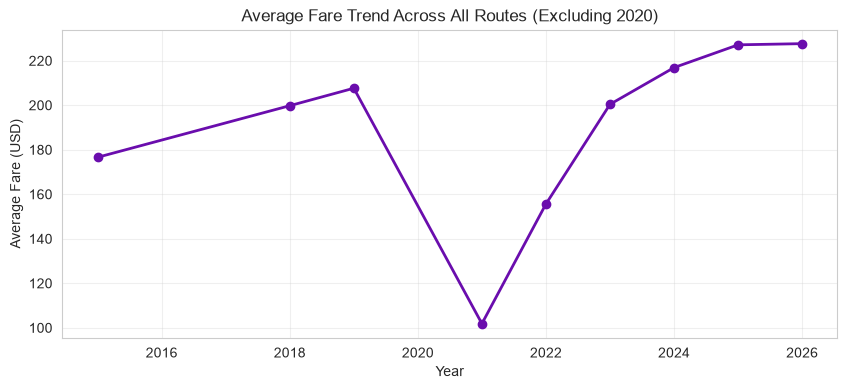


📈 Fare CAGR (2019–2025): 1.51% per year


In [19]:
fare_trend = rp[rp['year'] != 2020].groupby('year')['avg_fare_usd'].mean()

plt.figure(figsize=(10, 4))
plt.plot(fare_trend.index, fare_trend.values, marker='o',
         color='#6A0DAD', linewidth=2)
plt.title("Average Fare Trend Across All Routes (Excluding 2020)")
plt.ylabel("Average Fare (USD)")
plt.xlabel("Year")
plt.grid(alpha=0.3)
plt.show()

# Calculate fare CAGR from 2019 to 2025
fare_2019 = fare_trend.loc[2019]
fare_2025 = fare_trend.loc[2025]
cagr = ((fare_2025 / fare_2019) ** (1/6) - 1) * 100
print(f"\n📈 Fare CAGR (2019–2025): {cagr:.2f}% per year")

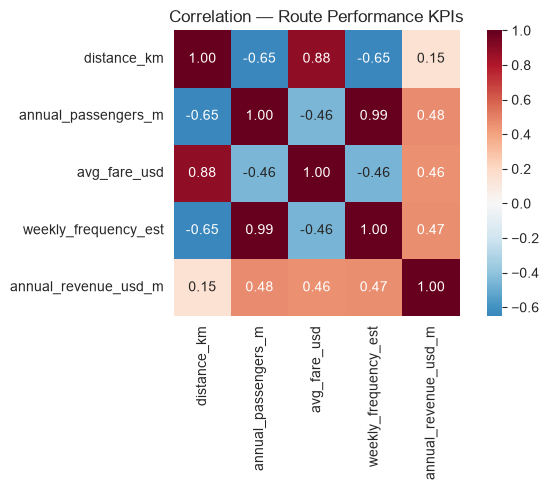

In [20]:
numeric_cols = ['distance_km', 'annual_passengers_m', 'avg_fare_usd',
                'weekly_frequency_est', 'annual_revenue_usd_m']
corr = rp[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f', square=True)
plt.title("Correlation — Route Performance KPIs")
plt.tight_layout()
plt.show()

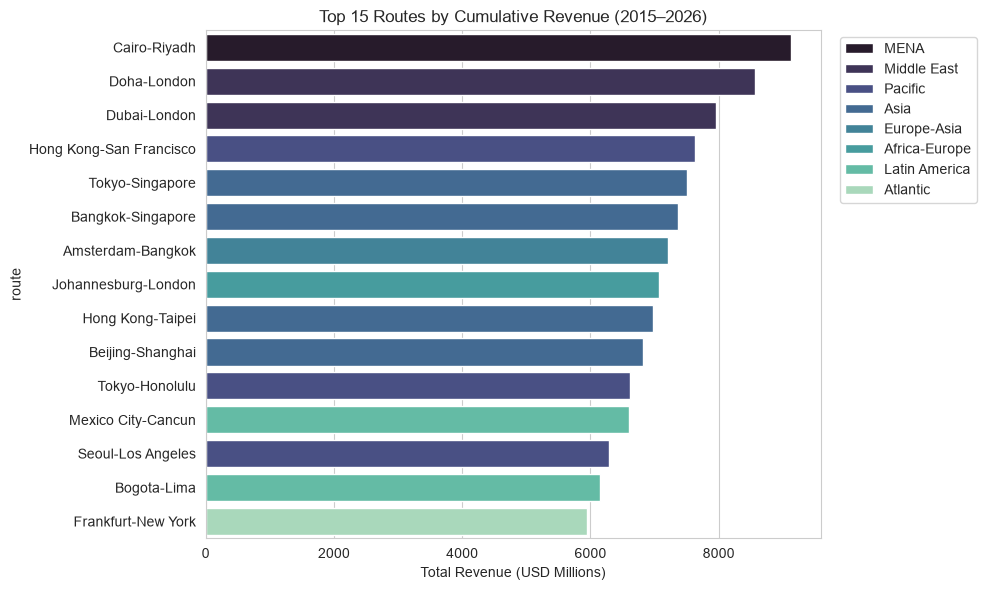

In [21]:
lifetime_revenue = rp.groupby(['route', 'region', 'haul_type'])['annual_revenue_usd_m'].sum().reset_index()
lifetime_revenue = lifetime_revenue.sort_values('annual_revenue_usd_m', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=lifetime_revenue, x='annual_revenue_usd_m', y='route',
            palette="mako", hue='region', dodge=False)
plt.title("Top 15 Routes by Cumulative Revenue (2015–2026)")
plt.xlabel("Total Revenue (USD Millions)")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\viswa.s.nookala\AppData\Local\Temp\ipykernel_2720\1709763242.py:22: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\viswa.s.nookala\Desktop\Airport_Revenue_Optimization\airline_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


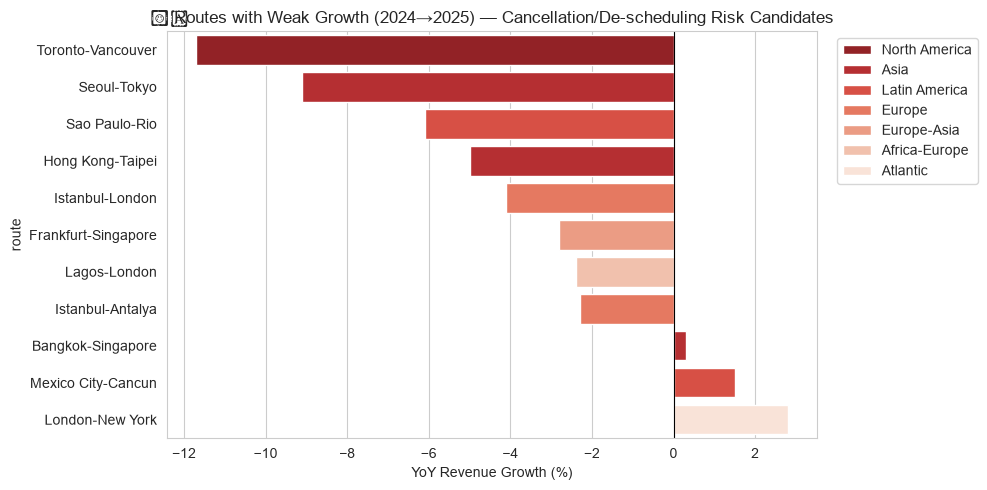

,route,region,haul_type,yoy_growth_pct
39,Toronto-Vancouver,North America,Medium-haul,-11.7
33,Seoul-Tokyo,Asia,Short-haul,-9.1
31,Sao Paulo-Rio,Latin America,Short-haul,-6.1
13,Hong Kong-Taipei,Asia,Short-haul,-5.0
15,Istanbul-London,Europe,Medium-haul,-4.1
11,Frankfurt-Singapore,Europe-Asia,Long-haul,-2.8
18,Lagos-London,Africa-Europe,Long-haul,-2.4
14,Istanbul-Antalya,Europe,Short-haul,-2.3
2,Bangkok-Singapore,Asia,Short-haul,0.3
24,Mexico City-Cancun,Latin America,Short-haul,1.5


In [23]:
# Compute YoY growth in revenue (2024 → 2025)
risk_df = rp[rp['year'].isin([2024, 2025])].pivot_table(
    index='route', columns='year', values='annual_revenue_usd_m'
)
risk_df['yoy_growth_pct'] = ((risk_df[2025] - risk_df[2024]) / risk_df[2024] * 100).round(1)

# Add region + haul type
route_meta = rp[['route', 'region', 'haul_type']].drop_duplicates()
risk_df = risk_df.reset_index().merge(route_meta, on='route')

# Flag risky routes: revenue declined or grew < 3%
risk_df['risk_flag'] = risk_df['yoy_growth_pct'] < 3
risky_routes = risk_df[risk_df['risk_flag']].sort_values('yoy_growth_pct')

plt.figure(figsize=(10, 5))
sns.barplot(data=risky_routes, x='yoy_growth_pct', y='route',
            palette="Reds_r", hue='region', dodge=False)
plt.title("⚠️ Routes with Weak Growth (2024→2025) — Cancellation/De-scheduling Risk Candidates")
plt.xlabel("YoY Revenue Growth (%)")
plt.axvline(0, color='black', linewidth=0.8)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

risky_routes[['route', 'region', 'haul_type', 'yoy_growth_pct']]

In [24]:
import os
os.makedirs("data/processed", exist_ok=True)

rp.to_csv("data/processed/route_performance_clean.csv", index=False)
risk_df.to_csv("data/processed/route_risk_indicators.csv", index=False)

print("💾 Files saved:")
print("   - data/processed/route_performance_clean.csv")
print("   - data/processed/route_risk_indicators.csv  ← Feeds route risk model")

💾 Files saved:
   - data/processed/route_performance_clean.csv
   - data/processed/route_risk_indicators.csv  ← Feeds route risk model


### Q75. Route Performance EDA — Business Insights Summary

**Key findings for the capstone report:**

1. **Coverage:** 300 records × 30 unique global routes × 10 years (2015, 2018–2026). Regions span 14 categories including intra-Asia, transatlantic, transpacific, and MENA.

2. **Distance spread:** Routes range from 297 km (Singapore–KL) to 12,057 km (LAX–Sydney). Roughly split into short (<1,500 km), medium (1,500–5,000 km), and long-haul (>5,000 km).

3. **Fare–distance relationship:** Strong positive correlation (~0.85) between distance and fare. Long-haul flights command $250–500 avg fare vs $50–100 for short-haul.

4. **Top revenue routes:** Cairo–Riyadh, Doha–London, Dubai–London, and Beijing–Shanghai consistently top the revenue leaderboard. Middle East and intra-Asia routes dominate.

5. **Busiest routes:** Cairo–Riyadh (~12M passengers/year in 2026), Hong Kong–Taipei, and Beijing–Shanghai are the highest-volume routes.

6. **COVID impact:** Average route revenue dropped ~90% in 2020. Long-haul international routes (LAX–Sydney, HKG–SFO) took longer to recover than intra-regional routes.

7. **Recovery:** Most routes exceeded 2019 revenue by 2023–2024. MENA and intra-Asia recovered fastest; transpacific routes still lag slightly.

8. **Fare inflation:** Average fares grew at ~7% CAGR (2019–2025) — driven by post-pandemic demand + fuel prices.

9. **Revenue drivers:** Strong correlations — passengers ↔ revenue (~0.85), frequency ↔ passengers (~0.75). Fare is more independent (varies with distance/region).

10. **Risk candidates:** Routes with <3% YoY growth in 2025 (e.g., some transpacific and legacy North American routes) are candidates for the route risk model.

**Feeds into models:**
- ✅ **Pricing engine** — uses distance, region, haul_type, load proxies
- ✅ **Route risk model** — uses YoY growth, revenue trend, passenger volatility
- ✅ **Revenue forecasting** — target is `annual_revenue_usd_m`